# 나만의 이미지 분류기 만들기 (초급)

##  학습 목표
이 실습에서는 인공지능이 이미지를 어떻게 분류하는지 배웁니다!

**배울 내용:**
1. 사전 학습된 AI 모델 사용하기
2. 이미지 데이터 준비하기
3. 모델 학습시키기
4. 결과 확인하기


### 사전 학습 모델이란?

마치 이미 많은 그림을 본 화가처럼, 이 AI 모델은 이미 수백만 장의 이미지로 학습되어 있습니다.

우리는 이 똑똑한 모델을 가져와서 우리의 문제(CIFAR-10 이미지 분류)에 맞게 **약간만 조정**하면 됩니다!

---

In [1]:
import os

os.cpu_count()

2

In [2]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [3]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

In [ ]:
# 런타임 재시작 하세요.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 나눔고딕 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

# matplotlib 기본 폰트로 지정
matplotlib.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료:", matplotlib.rcParams['font.family'])


한글 폰트 설정 완료: ['NanumGothic']


In [2]:
# 필요한 라이브러리 가져오기
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision  # 이미지 처리 도구
import torchvision.transforms as transforms  # 이미지 변환 도구
import torchvision.models as models  # 사전 학습된 모델

import matplotlib.pyplot as plt
import numpy as np  # 숫자 계산
from tqdm import tqdm  # 진행 상태 표시

# 결과를 항상 같게 만들기 (재현성)
torch.manual_seed(42)

# GPU 사용 가능한지 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cuda')

## 2단계: 이미지 데이터 준비하기

**CIFAR-10 데이터셋:**
- 10가지 종류의 물체 사진 (비행기, 자동차, 새, 고양이 등)
- 총 60,000장의 작은 이미지 (32x32 픽셀)
- 50,000장으로 학습, 10,000장으로 테스트

**이미지 변환:**
- 크기를 112x112로 키웁니다 (더 자세하게 볼 수 있도록)
- 좌우 반전으로 데이터를 늘립니다 (데이터 증강)
- 숫자로 변환하고 정규화합니다

In [4]:
# 이미지를 변환하는 방법 정의
# 훈련용 이미지 변환(데이터 증강)

train_transform =\
transforms.Compose([
    transforms.Resize(112),
    # 크기 112*112 조정
    transforms.RandomHorizontalFlip(), # 좌우 반전(50%)
    transforms.ToTensor(),             # 범위 [0,1]
    transforms.Normalize(
        mean = [0.485,0.456, 0.406],
        std = [0.229, 0.224, 0.225]
     )  # [-1,1]
])


test_transform =\
transforms.Compose([
    transforms.Resize(112),
    # 크기 112*112 조정
    transforms.ToTensor(),             # 범위 [0,1]
    transforms.Normalize(
        mean = [0.485,0.456, 0.406],
        std = [0.229, 0.224, 0.225]
     )  # [-1,1]
])

In [5]:
# 훈련 데이터 다운로드 및 준비

train_dataset =\
torchvision.datasets.CIFAR10(
    root = './data',
    train = True,
    download = True,
    transform = train_transform
)

test_dataset =\
torchvision.datasets.CIFAR10(
    root = './data',
    train = False,     # 테스트 데이터 사용
    download = True,
    transform = test_transform
)

100%|██████████| 170M/170M [00:03<00:00, 46.5MB/s]


In [6]:
# 데이터 로더 생성(batch_size 즉, 배치단위로 묶어서 제공)
# loader >> batch 생각나
train_loader =\
DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True, # 데이터 섞음
    num_workers = 2 # 병렬처리
)

test_loader =\
DataLoader(
    test_dataset,
    batch_size = 128,
    shuffle = False,# 데이터 섞지마 (건들지마)
    num_workers = 2 # 병렬처리
)

In [7]:
# 클래스 이름 (10가지 물체)
classes = ['비행기', '자동차', '새', '고양이', '사슴',
           '개', '개구리', '말', '배', '트럭']

print(f'   훈련 이미지: {len(train_dataset):,}장')
print(f'   테스트 이미지: {len(test_dataset):,}장')
print(f'   분류할 종류: {len(classes)}가지')
print(f'   배치 크기: {train_loader.batch_size}장씩')

   훈련 이미지: 50,000장
   테스트 이미지: 10,000장
   분류할 종류: 10가지
   배치 크기: 64장씩


In [8]:
# 데이터 미리 보기
def show_sample_images(loader, classes, num_images=8):
    # 데이터 가져오기
    images, labels = next(iter(loader))

    # 정규화 해제 (다시 원래 이미지로) >> [0,1]범위로 복원
    # 정규화 : x_norm = (x-x_mean) / sigma(std)
    # 정규화 해제 : x = x_norm * std + mean
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    # 채널별 평균(mean)  텐서 생성 : [3,1,1] (브로드캐스팅으로 각 픽셀에 채널별 평균 적용)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    # 채널별 표준편차(std)  텐서 생성 : [3,1,1] (브로드캐스팅으로 각 픽셀에 채널별 표준편차 적용)
    images = images * std + mean

    images = torch.clamp(images, 0, 1)
    # 값 범위를 고정(clamp) 시각화, 저장하기 전에 안전하게 [0,1] 구간 잘라냄
    # >> 즉, pixel 값이 범위 [0,1] 제한

    # 그리드로 표시
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    # 배치 이미지 텐서를 2*4 격자(grid) 시각화
    axes = axes.ravel()
    #axes가 2*4 배열 형태 , 편하게 1차원으로 평탄화
    # print(axes)

    for i in range(num_images):
        img = images[i].permute(1,2,0).numpy()
        # permute(1,2, 0) : (chw) >> (hwc) pytorch tensor 이미지 [n,c,h,w]
        axes[i].imshow(img)
        axes[i].set_title(f'{classes[labels[i]]}', fontsize=12)
        axes[i].axis('off')

    plt.show()

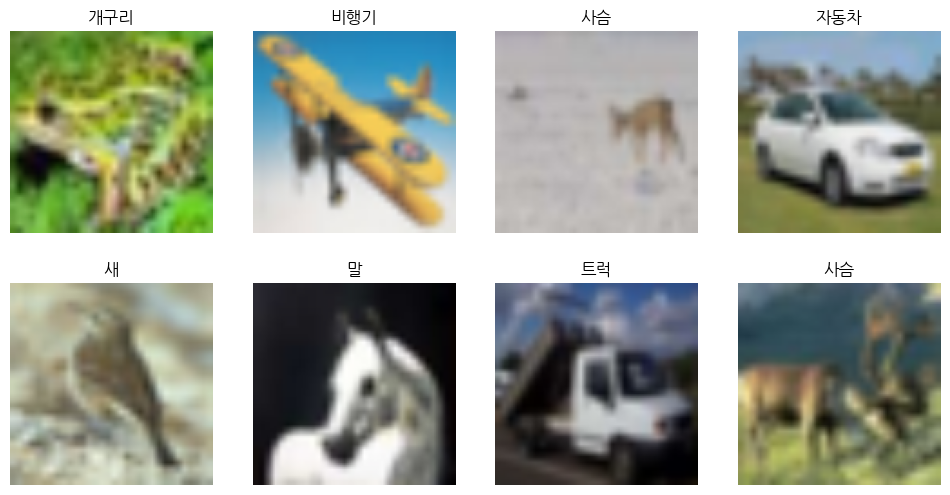

In [9]:
show_sample_images(train_loader, classes)

## 3단계: AI 모델 만들기

**MobileNetV2 모델:**
- 이미 수백만 장의 이미지로 학습된 똑똑한 모델
- 가볍고 빠른 모델 (모바일에서도 사용 가능)
- 마지막 부분만 우리 문제에 맞게 바꿔요

**왜 사전 학습 모델을 사용할까?**
- 처음부터 학습하면 시간이 너무 오래 걸려요 (몇 주일!)
- 이미 학습된 모델은 이미지의 기본 특징을 알고 있어요
- 우리는 마지막 부분만 조정하면 돼요 (몇 분!)

In [10]:
# 사전학습된 mobilenetv2 불러오기
# 전이학습 (Transfer Learning)
model = models.mobilenet_v2(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 150MB/s]


In [11]:
print(model)
'''
(classifier): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=1280, out_features=1000, bias=True)
  )
)
'''

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

'\n(classifier): Sequential(\n    (0): Dropout(p=0.2, inplace=False)\n    (1): Linear(in_features=1280, out_features=1000, bias=True)\n  )\n)\n'

In [12]:
print(model.classifier[1])
# 모델의 마지막 선형계층 의미

Linear(in_features=1280, out_features=1000, bias=True)


In [13]:
print(model.classifier[1].in_features)

1280


In [14]:
print(model.classifier[1].out_features)
# 분류할 클래스 개수
# 우리는 10개만 분류하면 되니깐 여기를 고쳐야 함

1000


In [15]:
num_features = model.classifier[1].in_features # 입력 특징 개수

In [16]:
model.classifier[1] = nn.Linear(num_features, 10) # 10개 클래스로 변경

model.classifier[1]

Linear(in_features=1280, out_features=10, bias=True)

In [17]:
# 모델을 gpu로 이동
model = model.to(device)

# 모델 파라미터 개수 확인
total_params = sum(p.numel()for p in model.parameters())
# p.numel() : 각 파라미터 텐서의 원소(숫자) 개수 반환
total_params # 223만개 숫자 학습

2236682

## 4단계: 학습 설정하기

모델을 학습시키기 위해 필요한 것들:

1. **손실 함수 (Loss Function):**
   - 모델이 얼마나 틀렸는지 계산
   - 숫자가 작을수록 잘 맞춘 것!

2. **최적화 함수 (Optimizer):**
   - 모델을 어떻게 개선할지 결정
   - SGD (Stochastic Gradient Descent) 사용

3. **학습률 (Learning Rate):**
   - 한 번에 얼마나 많이 배울지 조절
   - 0.001 = 천천히 조심스럽게 학습

In [18]:
# 손실 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# 몇 번 학습할거야?
num_epochs = 20

In [19]:
print('학습 설정 완료!')
print(f'  손실 함수: {criterion.__class__.__name__}')
print(f'  최적화 함수: {optimizer.__class__.__name__}')
print(f'  학습률: {optimizer.param_groups[0]["lr"]}')
# optimizer.param_groups[0] → 첫 번째 파라미터 그룹의 학습률(learning rate) 값
print(f'  학습 횟수: {num_epochs}번')

학습 설정 완료!
  손실 함수: CrossEntropyLoss
  최적화 함수: SGD
  학습률: 0.001
  학습 횟수: 20번


In [20]:
optimizer.param_groups[0]["lr"]

0.001

In [23]:
# 학습 기록을 저장할 리스트

train_losses = [] # 훈련손실
train_accs = []   # 훈련 정확도
test_accs = []    # 테스트 정확도

# epoch(학습횟수) 반복
for epoch in range(num_epochs):
    print(f'{epoch+1}/{num_epochs}')

    model.train() # 훈련용 모드

    running_loss = 0.0 # 손실 누적
    correct = 0        # 맞춘 개수
    total = 0          # 전체 개수

    for images, labels in tqdm(train_loader, desc='훈련중이예요'):
        images = images.to(device)
        labels = labels.to(device)

        # 1. 기울기 초기화
        optimizer.zero_grad()
        # 2. 순전파 : 모델이 예측
        outputs = model(images)
        # 3. 손실 계산
        loss = criterion(outputs, labels)
        # 4. 역전파 : 기울기 계산
        loss.backward()
        # 5. 가중치 업데이트
        optimizer.step()

        # 통계계산
        running_loss += loss.item() * images.size(0)
        # loss.item() 현재 배치 평균 손실 값 >> 파이썬 숫자로 변경
        # images.size(0) : 배치 크기

        _, predicted = torch.max(outputs, 1)
        # 각 샘플에 대해 가장 큰 logits(예측값)과 그 인덱스(예측 클래스) 반환
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # 테스트 단계
    model.eval() # 모델을 평가모드로 전환(dropout 비활성, BatchNorm 고정)
    correct = 0
    total = 0

    with torch.no_grad():
                # 기울기 계산 안 함(평가만)
        for images, labels in tqdm(test_loader, desc='테스트 중'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_accs.append(test_acc)

    # 결과 출력
    print(f'{epoch+1}:')
    print(f'훈련 손실: {epoch_loss:.4f}')
    print(f'훈련 정확도: {epoch_acc:.2f}%')
    print(f'테스트 정확도: {test_acc:.2f}%')
    print('-'*60)

print(test_accs[-1]) # 최종 테스트 정확도

1/20


테스트 중: 100%|██████████| 79/79 [00:08<00:00,  9.83it/s]


1:
훈련 손실: 0.0355
훈련 정확도: 98.84%
테스트 정확도: 94.03%
------------------------------------------------------------
2/20


테스트 중: 100%|██████████| 79/79 [00:06<00:00, 11.77it/s]


2:
훈련 손실: 0.0312
훈련 정확도: 98.99%
테스트 정확도: 93.64%
------------------------------------------------------------
3/20


...

18:
훈련 손실: 0.0070
훈련 정확도: 99.80%
테스트 정확도: 94.65%
------------------------------------------------------------
19/20


테스트 중: 100%|██████████| 79/79 [00:06<00:00, 11.62it/s]


19:
훈련 손실: 0.0058
훈련 정확도: 99.84%
테스트 정확도: 94.53%
------------------------------------------------------------
20/20


테스트 중: 100%|██████████| 79/79 [00:07<00:00, 10.60it/s]

20:
훈련 손실: 0.0056
훈련 정확도: 99.83%
테스트 정확도: 94.43%
------------------------------------------------------------
94.43


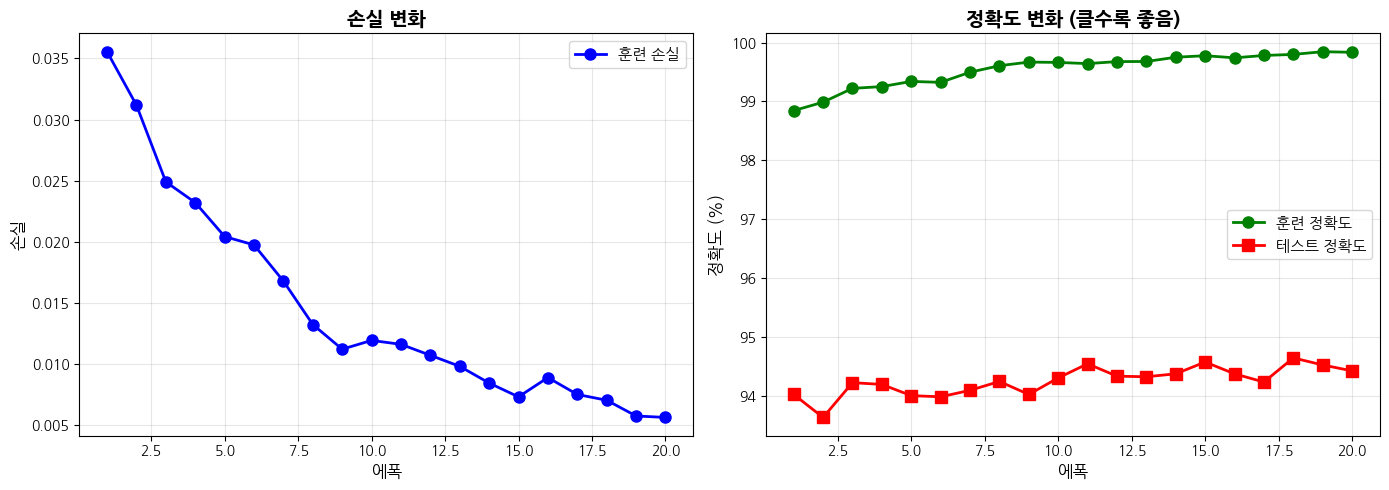


학습 결과 요약
시작 정확도: 94.03%
최종 정확도: 94.43%
향상도: +0.40%p
훌륭해요! 85% 이상의 정확도를 달성했습니다!


In [24]:
# 학습 곡선 그리기
def plot_results(train_losses, train_accs, test_accs):
    """
    학습 결과를 그래프로 그리는 함수
    """
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 손실 그래프
    axes[0].plot(epochs, train_losses, 'b-o', linewidth=2, markersize=8, label='훈련 손실')
    axes[0].set_xlabel('에폭', fontsize=12)
    axes[0].set_ylabel('손실', fontsize=12)
    axes[0].set_title('손실 변화', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # 정확도 그래프
    axes[1].plot(epochs, train_accs, 'g-o', linewidth=2, markersize=8, label='훈련 정확도')
    axes[1].plot(epochs, test_accs, 'r-s', linewidth=2, markersize=8, label='테스트 정확도')
    axes[1].set_xlabel('에폭', fontsize=12)
    axes[1].set_ylabel('정확도 (%)', fontsize=12)
    axes[1].set_title('정확도 변화 (클수록 좋음)', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 결과 요약
    print('\n학습 결과 요약')
    print('=' * 60)
    print(f'시작 정확도: {test_accs[0]:.2f}%')
    print(f'최종 정확도: {test_accs[-1]:.2f}%')
    print(f'향상도: {test_accs[-1] - test_accs[0]:+.2f}%p')
    print('=' * 60)

    # 해석
    if test_accs[-1] >= 85:
        print('훌륭해요! 85% 이상의 정확도를 달성했습니다!')
    elif test_accs[-1] >= 75:
        print('좋아요! 75% 이상의 정확도를 달성했습니다!')
    else:
        print('괜찮아요! 더 많은 에폭으로 학습하면 더 좋아질 거예요!')

# 그래프 그리기
plot_results(train_losses, train_accs, test_accs)

실제 예측하기

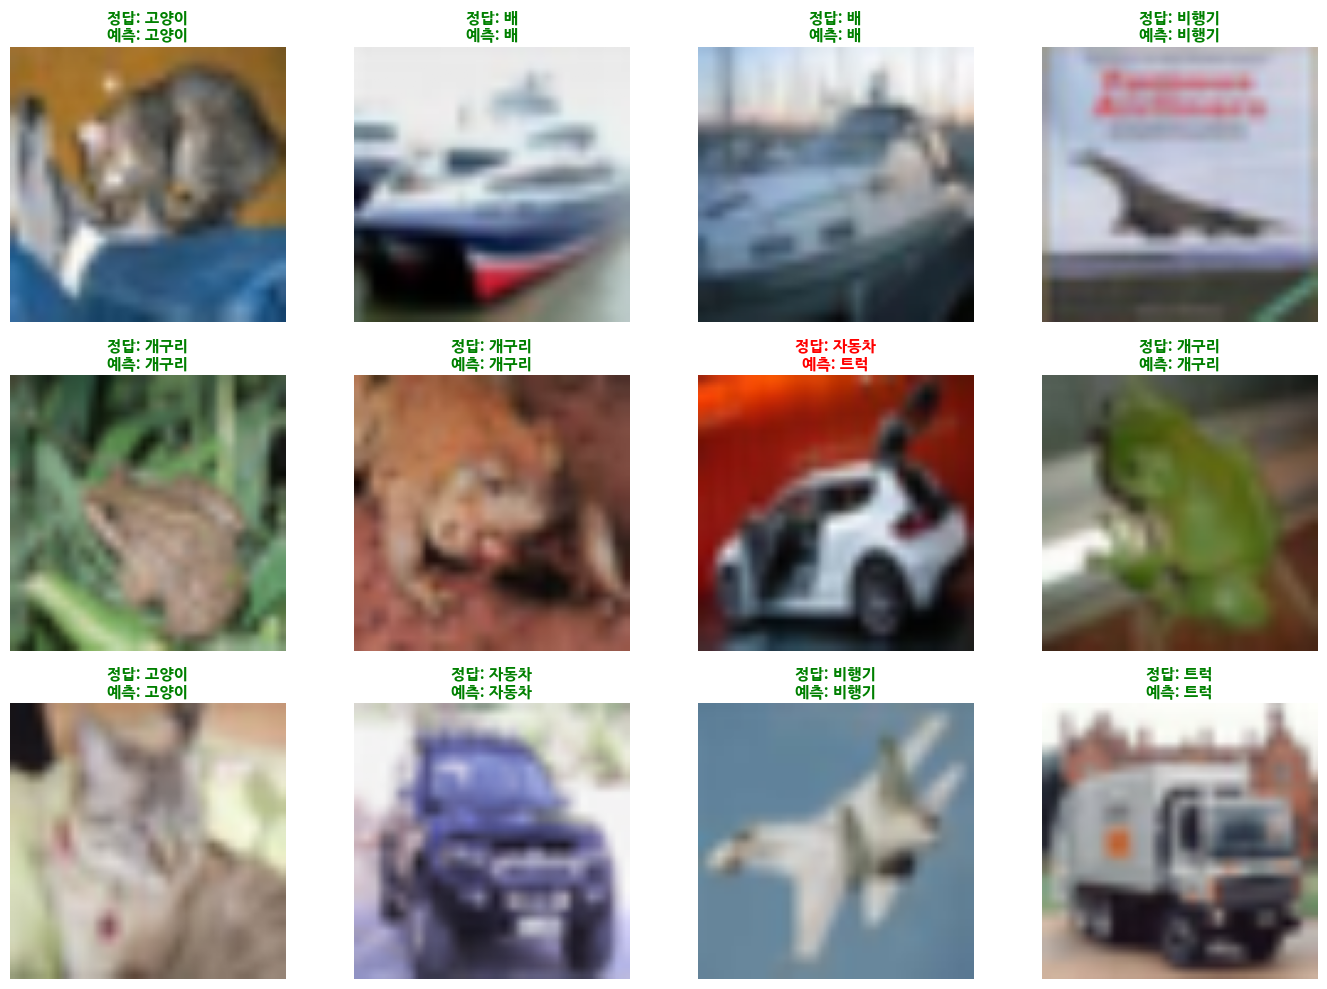


이 샘플에서 12개 중 11개를 맞췄어요!
정확도: 91.7%


In [25]:
# 예측 결과 시각화
def show_predictions(model, loader, classes, device, num_images=12):
    """
    모델의 예측 결과를 시각화하는 함수
    """
    model.eval()

    # 데이터 가져오기
    images, labels = next(iter(loader))
    images = images.to(device)

    # 예측
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    # CPU로 이동
    images = images.cpu()
    predicted = predicted.cpu()

    # 정규화 해제
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    # 시각화
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.ravel()

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)

        # 정답과 예측 비교
        true_label = classes[labels[i]]
        pred_label = classes[predicted[i]]

        # 맞으면 초록색, 틀리면 빨간색
        if labels[i] == predicted[i]:
            color = 'green'

        else:
            color = 'red'

        axes[i].set_title(
            f'정답: {true_label}\n예측: {pred_label}',
            color=color,
            fontsize=11,
            fontweight='bold'
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # 정확도 계산
    correct = (predicted[:num_images] == labels[:num_images]).sum().item()
    accuracy = 100 * correct / num_images

    print(f'\n이 샘플에서 {num_images}개 중 {correct}개를 맞췄어요!')
    print(f'정확도: {accuracy:.1f}%')

show_predictions(model, test_loader, classes, device, num_images=12)

클래스 별 성능 확인

In [28]:
cls = ['사람','고양이','개']
print(cls[0])
print([0]*len(cls))

사람
[0, 0, 0]


In [29]:
# 클래스별 정확도 계산
def evaluate_per_class(model, loader, classes, device):
    """
    클래스별 성능을 평가하는 함수
    """
    model.eval()

    # 클래스별 맞춘 개수와 전체 개수
    class_correct = [0] * len(classes)
    class_total = [0] * len(classes)

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='클래스별 평가'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            # 클래스별로 집계
            c = (predicted == labels)
            for i in range(len(labels)):
               label = labels[i]
               class_correct[label] += c[i].item()
               class_total[label] += 1

            # 코드 작성

    # 결과 출력
    print('\n클래스별 정확도')
    print('=' * 50)

    accuracies = []

    # 코드 작성
    for i, class_name in enumerate(classes):
        if class_total[i] > 0 :
          acc =100 * class_correct[i] / class_total[i]
          accuracies.append(acc)

          print(f'{class_name:8s} {acc:5.1f}%')

    print('=' * 50)
    print(f'평균 정확도: {np.mean(accuracies):.2f}%')

    # 가장 잘 맞추는 것과 어려워하는 것

    # 코드 작성
    best_idx = np.argmax(accuracies)
    worst_idx = np.argmin(accuracies)

    print(f'\n가장 잘 맞추는 것: {classes[best_idx]} ({accuracies[best_idx]:.1f}%)')
    print(f'가장 어려워하는 것: {classes[worst_idx]} ({accuracies[worst_idx]:.1f}%)')

# 클래스별 평가
evaluate_per_class(model, test_loader, classes, device)

클래스별 평가: 100%|██████████| 79/79 [00:08<00:00,  9.77it/s]


클래스별 정확도
비행기       96.4%
자동차       96.3%
새         91.9%
고양이       87.2%
사슴        95.2%
개         91.1%
개구리       97.4%
말         94.1%
배         97.0%
트럭        97.7%
평균 정확도: 94.43%

가장 잘 맞추는 것: 트럭 (97.7%)
가장 어려워하는 것: 고양이 (87.2%)


모델 저장하기

In [30]:
# 모델 저장
model_path = "my_image_classifer.pth"
torch.save(model.state_dict(), model_path)
# 코드 작성

print(f'모델 저장 완료: {model_path}')
print('\n나중에 이 모델을 불러오려면:')
print('```python')
print('model = models.mobilenet_v2()')
print('model.classifier[1] = nn.Linear(1280, 10)')
print(f'model.load_state_dict(torch.load("{model_path}"))')
print('model.eval()')
print('```')

모델 저장 완료: my_image_classifer.pth

나중에 이 모델을 불러오려면:
```python
model = models.mobilenet_v2()
model.classifier[1] = nn.Linear(1280, 10)
model.load_state_dict(torch.load("my_image_classifer.pth"))
model.eval()
```
